# A1

In [63]:
import math

def summation_unit(inputs, weights, bias):
    """
    Calculates the weighted sum:
    Z = bias + Σ(input * weight)
    """
    total = bias
    for i in range(len(inputs)):
        total += inputs[i] * weights[i]
    return total

def step_activation(x):
    """
    Step activation:
    Returns 1 if x >= 0, otherwise 0.
    """
    if x >= 0:
        return 1
    else:
        return 0

def bipolar_step_activation(x):
    """
    Bipolar Step activation:
    Returns 1 if x >= 0, otherwise -1.
    """
    if x >= 0:
        return 1
    else:
        return -1

def sigmoid_activation(x):
    """
    Sigmoid activation:
    f(x) = 1 / (1 + e^(-x))
    """
    return 1 / (1 + math.exp(-x))

def tanh_activation(x):
    """
    TanH activation.
    """
    return math.tanh(x)

def relu_activation(x):
    """
    ReLU activation:
    Returns x if x > 0, otherwise 0.
    """
    return max(0, x)

def leaky_relu_activation(x, alpha=0.01):
    """
    Leaky ReLU activation:
    Returns x if x > 0, otherwise alpha*x.
    """
    if x > 0:
        return x
    else:
        return alpha * x

def comparator_unit(actual, predicted):
    """
    Calculates the error between actual and predicted output.
    """
    return actual - predicted

inputs = [2, 3]
weights = [0.5, 0.2]
bias = 1

summed_value = summation_unit(inputs, weights, bias)

print("Summation value:", summed_value)
print("Step:", step_activation(summed_value))
print("Bipolar Step:", bipolar_step_activation(summed_value))
print("Sigmoid:", sigmoid_activation(summed_value))
print("TanH:", tanh_activation(summed_value))
print("ReLU:", relu_activation(summed_value))
print("Leaky ReLU:", leaky_relu_activation(summed_value))

actual_output = 1
predicted_output = 0

print("Error:", comparator_unit(actual_output, predicted_output))

Summation value: 2.6
Step: 1
Bipolar Step: 1
Sigmoid: 0.9308615796566533
TanH: 0.9890274022010992
ReLU: 2.6
Leaky ReLU: 2.6
Error: 1


# A2

In [64]:
def train_and_perceptron():
    inputs = [
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ]
    targets = [0, 0, 0, 1]
    w0 = 10
    w1 = 0.2
    w2 = -0.75
    learning_rate = 0.05
    max_epochs = 1000
    error_history = []
    for epoch in range(max_epochs):
        sum_squared_error = 0
        for i in range(len(inputs)):
            A = inputs[i][0]
            B = inputs[i][1]
            net = w0 + (w1 * A) + (w2 * B)
            if net >= 0:
                output = 1
            else:
                output = 0
            error = targets[i] - output
            w0 = w0 + learning_rate * error
            w1 = w1 + learning_rate * error * A
            w2 = w2 + learning_rate * error * B
            sum_squared_error += error ** 2
        error_history.append(sum_squared_error)
        if sum_squared_error <= 0.002:
            break
    return w0, w1, w2, error_history

w0, w1, w2, error_history = train_and_perceptron()

print("Final W0:", w0)
print("Final W1:", w1)
print("Final W2:", w2)
print("Number of epochs:", len(error_history))
print("Error values:", error_history)

Final W0: -0.10000000000000765
Final W1: 0.1000000000000001
Final W2: 0.05000000000000032
Number of epochs: 130
Error values: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 2, 1, 0]


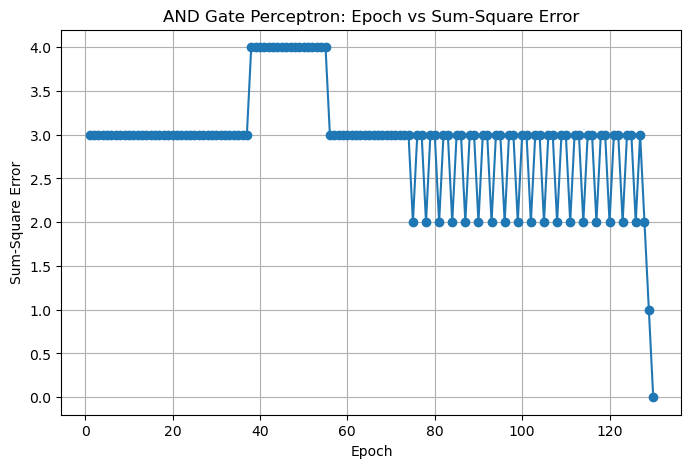

In [65]:
import matplotlib.pyplot as plt

epochs = range(1, len(error_history) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, error_history, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Sum-Square Error")
plt.title("AND Gate Perceptron: Epoch vs Sum-Square Error")
plt.grid(True)
plt.show()

# A3

In [66]:
def train_perceptron_a3(activation_function, targets):
    inputs = [
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ]
    w0 = 10
    w1 = 0.2
    w2 = -0.75
    learning_rate = 0.05
    max_epochs = 1000
    error_history = []
    for epoch in range(max_epochs):
        sum_squared_error = 0
        for i in range(len(inputs)):
            A = inputs[i][0]
            B = inputs[i][1]
            net = w0 + (w1 * A) + (w2 * B)
            output = activation_function(net)
            error = targets[i] - output
            w0 = w0 + learning_rate * error
            w1 = w1 + learning_rate * error * A
            w2 = w2 + learning_rate * error * B
            sum_squared_error += error ** 2
        error_history.append(sum_squared_error)
        if sum_squared_error <= 0.002:
            break
    return epoch + 1, error_history

bipolar_epochs, bipolar_errors = train_perceptron_a3(
    bipolar_step_activation,
    [-1, -1, -1, 1]
)

sigmoid_epochs, sigmoid_errors = train_perceptron_a3(
    sigmoid_activation,
    [0, 0, 0, 1]
)

relu_epochs, relu_errors = train_perceptron_a3(
    relu_activation,
    [0, 0, 0, 1]
)

print("Bipolar Step - Epochs:", bipolar_epochs)
print("Sigmoid - Epochs:", sigmoid_epochs)
print("ReLU - Epochs:", relu_epochs)

Bipolar Step - Epochs: 68
Sigmoid - Epochs: 1000
ReLU - Epochs: 390


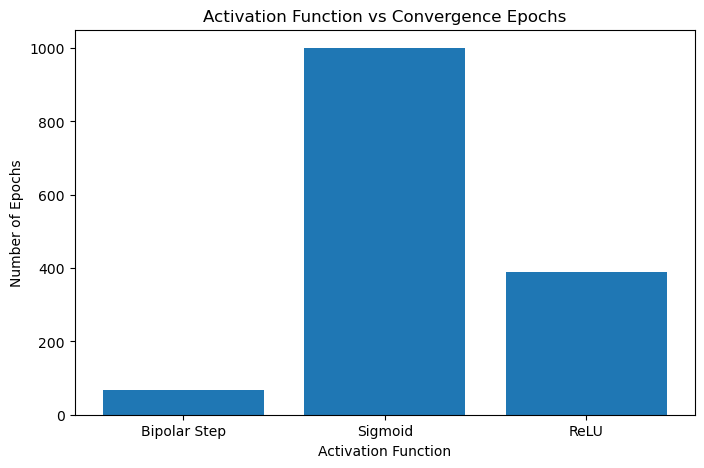

In [67]:
import matplotlib.pyplot as plt

activation_functions = [
    "Bipolar Step",
    "Sigmoid",
    "ReLU"
]

epochs = [
    bipolar_epochs,
    sigmoid_epochs,
    relu_epochs
]

plt.figure(figsize=(8, 5))
plt.bar(activation_functions, epochs)
plt.xlabel("Activation Function")
plt.ylabel("Number of Epochs")
plt.title("Activation Function vs Convergence Epochs")
plt.show()

# A4

In [68]:
def train_perceptron_learning_rate(learning_rate):

    inputs = [
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ]

    targets = [0, 0, 0, 1]
    w0 = 10
    w1 = 0.2
    w2 = -0.75
    max_epochs = 1000
    error_history = []
    for epoch in range(max_epochs):
        sum_squared_error = 0
        for i in range(len(inputs)):
            A = inputs[i][0]
            B = inputs[i][1]
            net = w0 + (w1 * A) + (w2 * B)
            if net >= 0:
                output = 1
            else:
                output = 0
            error = targets[i] - output
            w0 = w0 + learning_rate * error
            w1 = w1 + learning_rate * error * A
            w2 = w2 + learning_rate * error * B
            sum_squared_error += error ** 2
        error_history.append(sum_squared_error)
        if sum_squared_error <= 0.002:
            break
    return epoch + 1

learning_rates = [
    0.1, 0.2, 0.3, 0.4, 0.5,
    0.6, 0.7, 0.8, 0.9, 1.0
]

convergence_epochs = []

for lr in learning_rates:
    epochs = train_perceptron_learning_rate(lr)
    convergence_epochs.append(epochs)

for i in range(len(learning_rates)):
    print(
        "Learning Rate:",
        learning_rates[i],
        "-> Epochs:",
        convergence_epochs[i]
    )

Learning Rate: 0.1 -> Epochs: 68
Learning Rate: 0.2 -> Epochs: 37
Learning Rate: 0.3 -> Epochs: 23
Learning Rate: 0.4 -> Epochs: 23
Learning Rate: 0.5 -> Epochs: 19
Learning Rate: 0.6 -> Epochs: 19
Learning Rate: 0.7 -> Epochs: 15
Learning Rate: 0.8 -> Epochs: 14
Learning Rate: 0.9 -> Epochs: 13
Learning Rate: 1.0 -> Epochs: 12


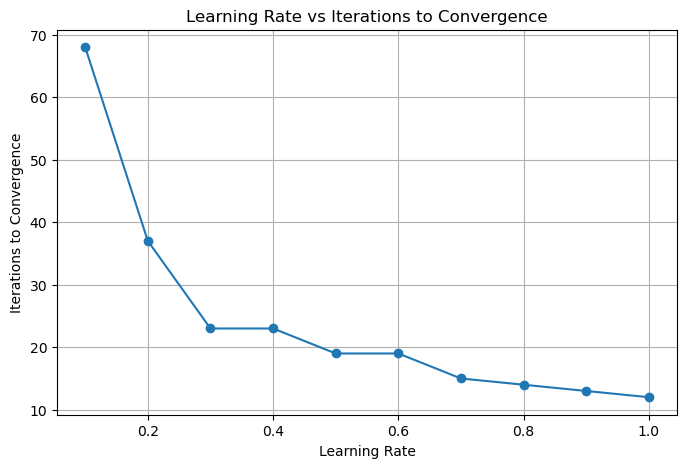

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    learning_rates,
    convergence_epochs,
    marker='o'
)

plt.xlabel("Learning Rate")
plt.ylabel("Iterations to Convergence")
plt.title("Learning Rate vs Iterations to Convergence")

plt.grid(True)
plt.show()

# A5

In [70]:
def train_xor_step():

    inputs = [
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ]

    targets = [0, 1, 1, 0]
    w0 = 10
    w1 = 0.2
    w2 = -0.75

    learning_rate = 0.05
    max_epochs = 1000

    error_history = []

    for epoch in range(max_epochs):
        sum_squared_error = 0
        for i in range(len(inputs)):
            A = inputs[i][0]
            B = inputs[i][1]
            net = w0 + (w1 * A) + (w2 * B)
            if net >= 0:
                output = 1
            else:
                output = 0
            error = targets[i] - output
            w0 = w0 + learning_rate * error
            w1 = w1 + learning_rate * error * A
            w2 = w2 + learning_rate * error * B
            sum_squared_error += error ** 2
        error_history.append(sum_squared_error)
        if sum_squared_error <= 0.002:
            break
    return w0, w1, w2, error_history

xor_w0, xor_w1, xor_w2, xor_error_history = train_xor_step()

print("Final W0:", xor_w0)
print("Final W1:", xor_w1)
print("Final W2:", xor_w2)
print("Number of epochs:", len(xor_error_history))
print("Final error:", xor_error_history[-1])

Final W0: 0.09999999999999236
Final W1: -0.09999999999999969
Final W2: -0.09999999999999969
Number of epochs: 1000
Final error: 4


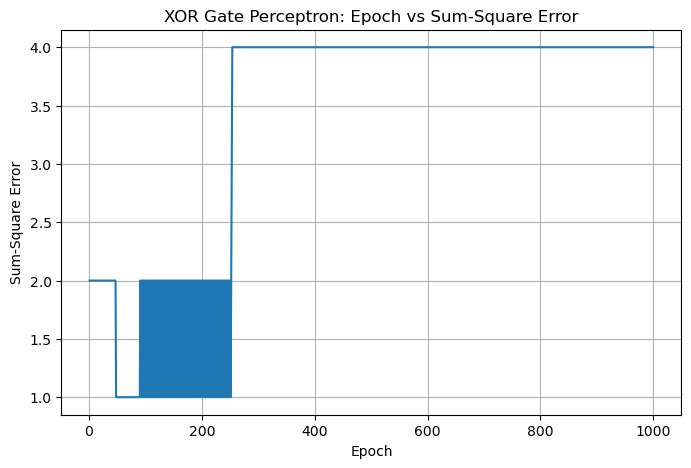

In [71]:
import matplotlib.pyplot as plt

epochs = range(1, len(xor_error_history) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    xor_error_history
)

plt.xlabel("Epoch")
plt.ylabel("Sum-Square Error")
plt.title("XOR Gate Perceptron: Epoch vs Sum-Square Error")
plt.grid(True)
plt.show()

In [72]:
def train_xor_activation(activation_function, targets):

    inputs = [
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ]

    w0 = 10
    w1 = 0.2
    w2 = -0.75

    learning_rate = 0.05
    max_epochs = 1000

    error_history = []

    for epoch in range(max_epochs):
        sum_squared_error = 0
        for i in range(len(inputs)):
            A = inputs[i][0]
            B = inputs[i][1]
            net = w0 + (w1 * A) + (w2 * B)
            
            output = activation_function(net)
            error = targets[i] - output
            
            w0 = w0 + learning_rate * error
            w1 = w1 + learning_rate * error * A
            w2 = w2 + learning_rate * error * B
            sum_squared_error += error ** 2
            
        error_history.append(sum_squared_error)
        if sum_squared_error <= 0.002:
            break
    return epoch + 1, error_history

bipolar_xor_epochs, bipolar_xor_errors = train_xor_activation(
    bipolar_step_activation,
    [-1, 1, 1, -1]
)

sigmoid_xor_epochs, sigmoid_xor_errors = train_xor_activation(
    sigmoid_activation,
    [0, 1, 1, 0]
)

relu_xor_epochs, relu_xor_errors = train_xor_activation(
    relu_activation,
    [0, 1, 1, 0]
)

print("Bipolar Step - Epochs:", bipolar_xor_epochs)
print("Sigmoid - Epochs:", sigmoid_xor_epochs)
print("ReLU - Epochs:", relu_xor_epochs)

Bipolar Step - Epochs: 1000
Sigmoid - Epochs: 1000
ReLU - Epochs: 1000


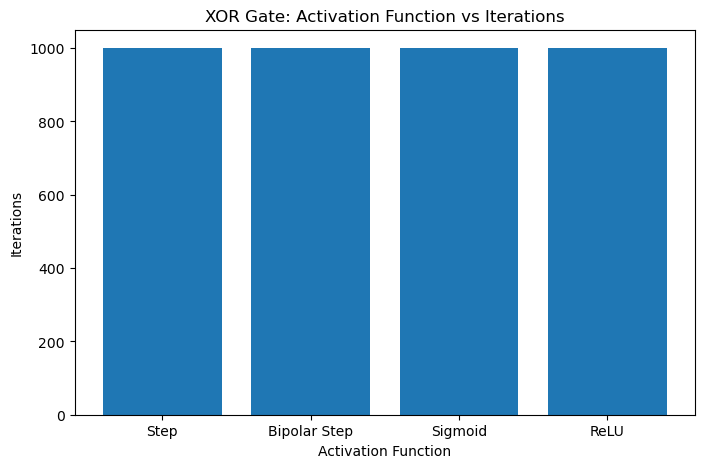

In [73]:
import matplotlib.pyplot as plt

activation_functions = [
    "Step",
    "Bipolar Step",
    "Sigmoid",
    "ReLU"
]

xor_epochs = [
    len(xor_error_history),
    bipolar_xor_epochs,
    sigmoid_xor_epochs,
    relu_xor_epochs
]

plt.figure(figsize=(8, 5))
plt.bar(activation_functions, xor_epochs)
plt.xlabel("Activation Function")
plt.ylabel("Iterations")
plt.title("XOR Gate: Activation Function vs Iterations")
plt.show()

# A6

In [74]:
customers = [
    [20, 6, 2, 386, 1],   
    [16, 3, 6, 289, 1],   
    [27, 6, 2, 393, 1],   
    [19, 1, 2, 110, 0],   
    [24, 4, 2, 280, 1],   
    [22, 1, 5, 167, 0],   
    [15, 4, 2, 271, 1],   
    [18, 4, 2, 274, 1],  
    [21, 1, 4, 148, 0],   
    [16, 2, 4, 198, 0]    
]

X = [row[:4] for row in customers]
y = [row[4] for row in customers]

print("Number of customers:", len(X))
print("Number of features:", len(X[0]))
print("Target values:", y)

Number of customers: 10
Number of features: 4
Target values: [1, 1, 1, 0, 1, 0, 1, 1, 0, 0]


In [75]:
X_normalized = []

for j in range(len(X[0])):
    column = [row[j] for row in X]
    minimum = min(column)
    maximum = max(column)
    normalized_column = []
    for value in column:
        normalized_value = (value - minimum) / (maximum - minimum)
        normalized_column.append(normalized_value)
    X_normalized.append(normalized_column)

X_normalized = [
    [X_normalized[j][i] for j in range(len(X[0]))]
    for i in range(len(X))
]

print("Normalized data:")
for i in range(len(X_normalized)):
    print("C" + str(i + 1), X_normalized[i])

Normalized data:
C1 [0.4166666666666667, 1.0, 0.0, 0.9752650176678446]
C2 [0.08333333333333333, 0.4, 1.0, 0.6325088339222615]
C3 [1.0, 1.0, 0.0, 1.0]
C4 [0.3333333333333333, 0.0, 0.0, 0.0]
C5 [0.75, 0.6, 0.0, 0.6007067137809188]
C6 [0.5833333333333334, 0.0, 0.75, 0.20141342756183744]
C7 [0.0, 0.6, 0.0, 0.568904593639576]
C8 [0.25, 0.6, 0.0, 0.5795053003533569]
C9 [0.5, 0.0, 0.5, 0.13427561837455831]
C10 [0.08333333333333333, 0.2, 0.5, 0.31095406360424027]


In [76]:
def train_customer_perceptron(X, y):
    weights = [0, 0, 0, 0]
    bias = 0
    learning_rate = 0.1
    max_epochs = 1000
    error_history = []
    
    for epoch in range(max_epochs):
        sum_squared_error = 0
        for i in range(len(X)):
            net = bias
            for j in range(len(X[i])):
                net += weights[j] * X[i][j]
            output = sigmoid_activation(net)
            error = y[i] - output
            for j in range(len(weights)):
                weights[j] = weights[j] + learning_rate * error * X[i][j]
            bias = bias + learning_rate * error
            sum_squared_error += error ** 2
        error_history.append(sum_squared_error)
        if sum_squared_error <= 0.002:
            break
    return weights, bias, error_history

customer_weights, customer_bias, customer_error_history = train_customer_perceptron(
    X_normalized,
    y
)

print("Final weights:", customer_weights)
print("Final bias:", customer_bias)
print("Number of epochs:", len(customer_error_history))
print("Final error:", customer_error_history[-1])

Final weights: [-0.7110105994644669, 9.357694129134611, -0.5902687164494967, 9.001346286495876]
Final bias: -6.261647086066074
Number of epochs: 1000
Final error: 0.022137934671815462


In [77]:
def predict_customer(X, weights, bias):
    predictions = []
    probabilities = []
    for row in X:
        net = bias
        for j in range(len(row)):
            net += weights[j] * row[j]
        probability = sigmoid_activation(net)
        if probability >= 0.5:
            prediction = 1
        else:
            prediction = 0
        probabilities.append(probability)
        predictions.append(prediction)
    return predictions, probabilities

predictions, probabilities = predict_customer(
    X_normalized,
    customer_weights,
    customer_bias
)

for i in range(len(predictions)):
    if predictions[i] == 1:
        transaction_class = "High"
    else:
        transaction_class = "Low"

    print(
        "C" + str(i + 1),
        "Probability:", round(probabilities[i], 4),
        "->", transaction_class
    )

C1 Probability: 1.0 -> High
C2 Probability: 0.9259 -> High
C3 Probability: 1.0 -> High
C4 Probability: 0.0015 -> Low
C5 Probability: 0.9856 -> High
C6 Probability: 0.0049 -> Low
C7 Probability: 0.9887 -> High
C8 Probability: 0.9878 -> High
C9 Probability: 0.0033 -> Low
C10 Probability: 0.125 -> Low


# A7

In [78]:
import numpy as np
X_matrix = np.array(X_normalized)
X_with_bias = np.column_stack((np.ones(len(X_matrix)), X_matrix))
y_matrix = np.array(y)
pseudo_inverse_weights = np.linalg.pinv(X_with_bias) @ y_matrix

print("Pseudo-Inverse Weights:")
print(pseudo_inverse_weights)

Pseudo-Inverse Weights:
[ 0.10693353 -0.30835084  0.67960257 -0.01429023  0.64216914]


In [79]:
def predict_pseudo_inverse(X, weights):
    predictions = []
    for row in X:
        row_with_bias = [1] + row
        prediction = 0
        for j in range(len(row_with_bias)):
            prediction += row_with_bias[j] * weights[j]
        if prediction >= 0.5:
            class_prediction = 1
        else:
            class_prediction = 0
        predictions.append(class_prediction)
    return predictions

pseudo_predictions = predict_pseudo_inverse(
    X_normalized,
    pseudo_inverse_weights
)

for i in range(len(pseudo_predictions)):
    if pseudo_predictions[i] == 1:
        transaction_class = "High"
    else:
        transaction_class = "Low"

    print("C" + str(i + 1), "->", transaction_class)

C1 -> High
C2 -> High
C3 -> High
C4 -> Low
C5 -> High
C6 -> Low
C7 -> High
C8 -> High
C9 -> Low
C10 -> Low


In [80]:
perceptron_correct = 0
pseudo_inverse_correct = 0

for i in range(len(y)):
    if predictions[i] == y[i]:
        perceptron_correct += 1
    if pseudo_predictions[i] == y[i]:
        pseudo_inverse_correct += 1

perceptron_accuracy = (perceptron_correct / len(y)) * 100
pseudo_inverse_accuracy = (pseudo_inverse_correct / len(y)) * 100

print("Perceptron Accuracy:", perceptron_accuracy, "%")
print("Pseudo-Inverse Accuracy:", pseudo_inverse_accuracy, "%")

Perceptron Accuracy: 100.0 %
Pseudo-Inverse Accuracy: 100.0 %


# A8

In [81]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

T = np.array([0, 0, 0, 1], dtype=float)

alpha = 0.05
max_iterations = 1000
error_limit = 0.002

np.random.seed(42)

V11 = np.random.uniform(-0.05, 0.05)
V12 = np.random.uniform(-0.05, 0.05)
V21 = np.random.uniform(-0.05, 0.05)
V22 = np.random.uniform(-0.05, 0.05)

W1 = np.random.uniform(-0.05, 0.05)
W2 = np.random.uniform(-0.05, 0.05)

for iteration in range(1, max_iterations + 1):
    total_error = 0
    for i in range(len(X)):
        A = X[i][0]
        B = X[i][1]
        target = T[i]

        net_H1 = A * V11 + B * V21
        net_H2 = A * V12 + B * V22
        H1 = sigmoid(net_H1)
        H2 = sigmoid(net_H2)
        net_O = H1 * W1 + H2 * W2
        output = sigmoid(net_O)

        error = 0.5 * (target - output) ** 2
        total_error += error

        delta_O = output * (1 - output) * (target - output)
        delta_H1 = H1 * (1 - H1) * W1 * delta_O
        delta_H2 = H2 * (1 - H2) * W2 * delta_O
        W1 = W1 + alpha * delta_O * H1
        W2 = W2 + alpha * delta_O * H2
        V11 = V11 + alpha * delta_H1 * A
        V21 = V21 + alpha * delta_H1 * B
        V12 = V12 + alpha * delta_H2 * A
        V22 = V22 + alpha * delta_H2 * B

    average_error = total_error / len(X)
    if iteration == 1 or iteration % 100 == 0:
        print(
            "Iteration:", iteration,
            "Error:", round(average_error, 6)
        )
    if average_error <= error_limit:
        print("\nTraining converged!")
        print("Iterations:", iteration)
        print("Error:", average_error)
        break
else:
    print("\nTraining stopped after 1000 iterations.")
    print("Final Error:", average_error)

print("\nFinal Weights")
print("----------------------")
print("V11 =", V11)
print("V12 =", V12)
print("V21 =", V21)
print("V22 =", V22)
print("W1  =", W1)
print("W2  =", W2)

print("\nAND Gate Results")
print("----------------------")

for i in range(len(X)):
    A = X[i][0]
    B = X[i][1]
    H1 = sigmoid(A * V11 + B * V21)
    H2 = sigmoid(A * V12 + B * V22)
    output = sigmoid(H1 * W1 + H2 * W2)

    print(
        "Input =", [int(A), int(B)],
        "Output =", round(output, 4),
        "Target =", int(T[i])
    )

Iteration: 1 Error: 0.122902
Iteration: 100 Error: 0.10286
Iteration: 200 Error: 0.096282
Iteration: 300 Error: 0.092521
Iteration: 400 Error: 0.089187
Iteration: 500 Error: 0.085824
Iteration: 600 Error: 0.082463
Iteration: 700 Error: 0.079253
Iteration: 800 Error: 0.076321
Iteration: 900 Error: 0.073733
Iteration: 1000 Error: 0.071496

Training stopped after 1000 iterations.
Final Error: 0.07149584390175244

Final Weights
----------------------
V11 = -0.8315422241263304
V12 = -0.7744323184520212
V21 = -0.7907066116865183
V22 = -0.8152962155370798
W1  = -1.6316324136982034
W2  = -1.5982388030105137

AND Gate Results
----------------------
Input = [0, 0] Output = 0.1659 Target = 0
Input = [0, 1] Output = 0.2691 Target = 0
Input = [1, 0] Output = 0.2691 Target = 0
Input = [1, 1] Output = 0.3682 Target = 1


# A9

In [82]:
X = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]

y = [0, 1, 1, 0]

weights = [0, 0]
bias = 0

learning_rate = 0.1
max_epochs = 1000

error_history = []

for epoch in range(max_epochs):
    total_error = 0
    for i in range(len(X)):
        net = summation_unit(
            X[i],
            weights,
            bias
        )
        output = sigmoid_activation(net)
        error = y[i] - output
        total_error += error ** 2

        for j in range(len(weights)):
            weights[j] = (
                weights[j]
                + learning_rate * error * X[i][j]
            )
        bias = bias + learning_rate * error

    error_history.append(total_error)
    if total_error <= 0.002:
        print("Training converged!")
        break

print("Final weights:", weights)
print("Final bias:", bias)
print("Number of epochs:", len(error_history))
print("Final error:", error_history[-1])
print("\nXOR Gate Results")
print("-----------------------------")

for i in range(len(X)):
    net = summation_unit(X[i], weights, bias)
    output = sigmoid_activation(net)
    if output >= 0.5:
        prediction = 1
    else:
        prediction = 0

    print(
        "Input:", X[i],
        "Output:", round(output, 4),
        "Prediction:", prediction,
        "Target:", y[i]
    )

Final weights: [-0.10256351949290327, -0.05128175621298492]
Final bias: 0.051281754708584835
Number of epochs: 1000
Final error: 1.051927694388316

XOR Gate Results
-----------------------------
Input: [0, 0] Output: 0.5128 Prediction: 1 Target: 0
Input: [0, 1] Output: 0.5 Prediction: 0 Target: 1
Input: [1, 0] Output: 0.4872 Prediction: 0 Target: 1
Input: [1, 1] Output: 0.4744 Prediction: 0 Target: 0


# A10

In [83]:
import math

def summation_unit(inputs, weights, bias):
    """
    Calculates the weighted sum:
    Z = bias + Σ(input * weight)
    """
    total = bias

    for i in range(len(inputs)):
        total += inputs[i] * weights[i]

    return total

def step_activation(x):
    """
    Step activation:
    Returns 1 if x >= 0, otherwise 0.
    """
    if x >= 0:
        return 1
    else:
        return 0

def bipolar_step_activation(x):
    """
    Bipolar Step activation:
    Returns 1 if x >= 0, otherwise -1.
    """
    if x >= 0:
        return 1
    else:
        return -1

def sigmoid_activation(x):
    """
    Sigmoid activation:
    f(x) = 1 / (1 + e^(-x))
    """
    return 1 / (1 + math.exp(-x))

def tanh_activation(x):
    """
    TanH activation.
    """
    return math.tanh(x)

def relu_activation(x):
    """
    ReLU activation:
    Returns x if x > 0, otherwise 0.
    """
    return max(0, x)

def leaky_relu_activation(x, alpha=0.01):
    """
    Leaky ReLU activation:
    Returns x if x > 0, otherwise alpha*x.
    """
    if x > 0:
        return x
    else:
        return alpha * x

def comparator_unit(actual, predicted):
    """
    Calculates the error between actual and predicted output.
    """
    return actual - predicted

def train_and_perceptron_two_outputs():
    inputs = [
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ]
    targets = [
        [1, 0],
        [1, 0],
        [1, 0],
        [0, 1]
    ]

    w01 = 10
    w11 = 0.2
    w21 = -0.75
    w02 = 10
    w12 = 0.2
    w22 = -0.75

    learning_rate = 0.05
    max_epochs = 1000
    error_history = []

    for epoch in range(max_epochs):
        sum_squared_error = 0
        for i in range(len(inputs)):
            A = inputs[i][0]
            B = inputs[i][1]

            net_O1 = summation_unit(
                [A, B],
                [w11, w21],
                w01
            )
            O1 = step_activation(net_O1)
            error_O1 = comparator_unit(
                targets[i][0],
                O1
            )
            w01 = w01 + learning_rate * error_O1
            w11 = w11 + learning_rate * error_O1 * A
            w21 = w21 + learning_rate * error_O1 * B

            net_O2 = summation_unit(
                [A, B],
                [w12, w22],
                w02
            )
            O2 = step_activation(net_O2)
            error_O2 = comparator_unit(
                targets[i][1],
                O2
            )
            w02 = w02 + learning_rate * error_O2
            w12 = w12 + learning_rate * error_O2 * A
            w22 = w22 + learning_rate * error_O2 * B
            sum_squared_error += error_O1 ** 2
            sum_squared_error += error_O2 ** 2
        error_history.append(sum_squared_error)
        if sum_squared_error <= 0.002:
            break
    return (
        w01, w11, w21,
        w02, w12, w22,
        error_history
    )

(
    w01, w11, w21,
    w02, w12, w22,
    error_history
) = train_and_perceptron_two_outputs()

print("Final weights for O1")
print("-------------------------")
print("W01:", w01)
print("W11:", w11)
print("W21:", w21)

print("\nFinal weights for O2")
print("-------------------------")
print("W02:", w02)
print("W12:", w12)
print("W22:", w22)

print("\nNumber of epochs:", len(error_history))
print("Final error:", error_history[-1])

inputs = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]

targets = [
    [1, 0],
    [1, 0],
    [1, 0],
    [0, 1]
]

print("\nAND Gate Results")
print("--------------------------------")

for i in range(len(inputs)):
    A = inputs[i][0]
    B = inputs[i][1]

    net_O1 = summation_unit(
        [A, B],
        [w11, w21],
        w01
    )
    O1 = step_activation(net_O1)

    net_O2 = summation_unit(
        [A, B],
        [w12, w22],
        w02
    )
    O2 = step_activation(net_O2)

    print(
        "Input:", inputs[i],
        "Output:", [O1, O2],
        "Target:", targets[i]
    )

Final weights for O1
-------------------------
W01: 6.8499999999999766
W11: -2.9499999999999975
W21: -3.899999999999994

Final weights for O2
-------------------------
W02: -0.10000000000000765
W12: 0.1000000000000001
W22: 0.05000000000000032

Number of epochs: 130
Final error: 0

AND Gate Results
--------------------------------
Input: [0, 0] Output: [1, 0] Target: [1, 0]
Input: [0, 1] Output: [1, 0] Target: [1, 0]
Input: [1, 0] Output: [1, 0] Target: [1, 0]
Input: [1, 1] Output: [0, 1] Target: [0, 1]


# A11

In [84]:
from sklearn.neural_network import MLPClassifier

X = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]

# AND 
y = [0, 0, 0, 1]

model = MLPClassifier(
    hidden_layer_sizes=(2,),
    activation='logistic',
    solver='sgd',
    learning_rate_init=0.05,
    max_iter=1000,
    random_state=42
)

model.fit(X, y)

predictions = model.predict(X)

print("AND Gate Results")
print("-----------------------------")

for i in range(len(X)):
    print(
        "Input:", X[i],
        "Predicted:", predictions[i],
        "Target:", y[i]
    )

accuracy = model.score(X, y)

print("\nAccuracy:", accuracy * 100, "%")
print("Number of iterations:", model.n_iter_)

AND Gate Results
-----------------------------
Input: [0, 0] Predicted: 0 Target: 0
Input: [0, 1] Predicted: 0 Target: 0
Input: [1, 0] Predicted: 0 Target: 0
Input: [1, 1] Predicted: 1 Target: 1

Accuracy: 100.0 %
Number of iterations: 513


In [85]:
from sklearn.neural_network import MLPClassifier

X = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]

# XOR
y = [0, 1, 1, 0]

model = MLPClassifier(
    hidden_layer_sizes=(2,),
    activation='logistic',
    solver='adam',
    learning_rate_init=0.05,
    max_iter=5000,
    random_state=42
)

model.fit(X, y)

predictions = model.predict(X)

print("XOR Gate Results")
print("-----------------------------")

for i in range(len(X)):
    print(
        "Input:", X[i],
        "Predicted:", predictions[i],
        "Target:", y[i]
    )

accuracy = model.score(X, y)

print("\nAccuracy:", accuracy * 100, "%")
print("Number of iterations:", model.n_iter_)

XOR Gate Results
-----------------------------
Input: [0, 0] Predicted: 0 Target: 0
Input: [0, 1] Predicted: 1 Target: 1
Input: [1, 0] Predicted: 1 Target: 1
Input: [1, 1] Predicted: 0 Target: 0

Accuracy: 100.0 %
Number of iterations: 272


# A12

True
Number of audio files: 3014
MLP Accuracy: 99.33665008291874 %
Number of iterations: 95

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.99      0.99       302
       Spoof       0.99      0.99      0.99       301

    accuracy                           0.99       603
   macro avg       0.99      0.99      0.99       603
weighted avg       0.99      0.99      0.99       603



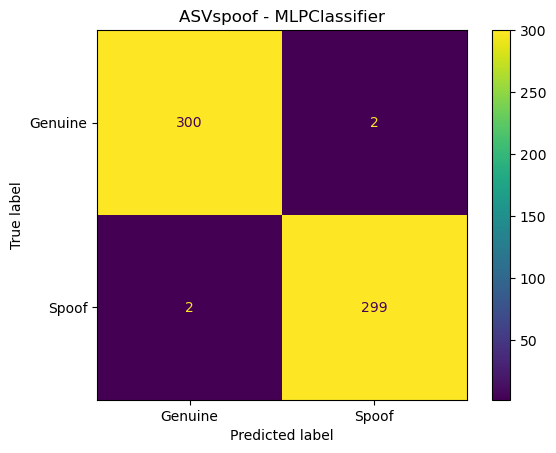

In [86]:
import os
import numpy as np
import pandas as pd
import librosa

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def extract_mfcc_features(file_path):
    signal, sample_rate = librosa.load(
        file_path,
        sr=None
    )
    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sample_rate,
        n_mfcc=13
    )
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)
    features = np.concatenate([
        mfcc_mean,
        mfcc_std
    ])
    return features

train_path = r"D:\ASV_2017\baseline_CM\baseline_CM\ASVspoof2017_V2_train"
print(os.path.exists(train_path))

data = []
for filename in os.listdir(train_path):
    if filename.lower().endswith(".wav"):
        file_path = os.path.join(
            train_path,
            filename
        )
        features = extract_mfcc_features(
            file_path
        )
        data.append(
            [filename] + features.tolist()
        )

print("Number of audio files:", len(data))

feature_names = []
for i in range(1, 14):
    feature_names.append(f"MFCC_{i}_mean")
for i in range(1, 14):
    feature_names.append(f"MFCC_{i}_std")

columns = ["filename"] + feature_names

df = pd.DataFrame(
    data,
    columns=columns
)

protocol_path = r"D:\ASV_2017\baseline_CM\baseline_CM\protocol_V2\ASVspoof2017_V2_train.trn.txt"

protocol_data = []
with open(protocol_path, "r") as file:
    for line in file:
        parts = line.strip().split()
        filename = parts[0]
        label = parts[1]
        protocol_data.append([filename, label])

protocol_df = pd.DataFrame(
    protocol_data,
    columns=["filename", "label"]
)

df = df.merge(
    protocol_df,
    on="filename",
    how="inner"
)

X = df[feature_names].to_numpy()
Y = df["label"]

Y = Y.map({
    "genuine": 0,
    "spoof": 1
})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("MLP Accuracy:", accuracy * 100, "%")
print("Number of iterations:", model.n_iter_)
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Genuine", "Spoof"]
    )
)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Spoof"]
)

disp.plot()
plt.title("ASVspoof - MLPClassifier")
plt.show()